In [1]:
import os
from pathlib import Path
from nd2reader import ND2Reader
import napari
import numpy as np
from cellpose import models

from skimage.measure import regionprops_table, regionprops
from skimage.io import imsave,imread
from skimage.segmentation import clear_border
from skimage.filters import gaussian
from skimage.morphology import remove_small_objects
import pandas as pd
from statannotations.Annotator import Annotator

import seaborn as sns
import matplotlib.pyplot as plt

import scipy.stats as stats

In [2]:
import torch
torch.cuda.is_available()

True

In [3]:
model = models.CellposeModel(gpu=True)

In [ ]:
im_dir = r'../2026_Raquel_coloc_data/data/IF_RBG_172/IF_RBG_172'
masks_dir = r'../2026_Raquel_coloc_data/masks/IF_RBG_172'
save_path = r'../2026_Raquel_coloc_data/260512_172_quant.csv'

In [ ]:
# create masks dir if it doesn't exist
try:
    os.mkdir(masks_dir)
except:
    print('masks directory already exists')

masks directory already exists


In [ ]:
# find the number of image sets
im_name_list = [str(file) for file in Path(im_dir).rglob('*') if file.is_file() and (('DAPI' in str(file)) or ('DMSO' in str(file)))]    
len(im_name_list)

25

In [ ]:
df_list = []

for im_dapi_path in im_name_list:

    # get the matching cy3 image
    im_cy_path = im_dapi_path.replace('DAPI','CY3').replace('DMSO','CY3')
    im_fitc_path = im_dapi_path.replace('DAPI','FITC')

    # get dapi name
    im_dapi_name = Path(im_dapi_path).name

    # open images
    im_dapi = np.array(ND2Reader(im_dapi_path))
    try:
        im_cy = np.array(ND2Reader(im_cy_path))
        im_fitc = np.array(ND2Reader(im_fitc_path))
        print(f'Image {im_fitc_path} opened.')
        
    except:
        im_fitc_path = im_dapi_path.replace('DAPI','AF488')
        im_fitc = np.array(ND2Reader(im_fitc_path))

        print(f'Image {im_fitc_path} opened.')

    # normalize DAPI image
    p3, p97 = np.percentile(im_dapi, [3, 99.9])
    p97 = 4000
    img_clipped = np.clip(im_dapi, p3, p97)
    im_dapi_norm = (img_clipped - p3) / (p97 - p3)

    # normalize cy3 image
    p3, p97 = np.percentile(im_cy, [3, 99.9])
    img_clipped = np.clip(im_cy, p3, p97)
    im_cy_norm = (img_clipped - p3) / (p97 - p3)

    # normalize fitc image
    p3, p97 = np.percentile(im_fitc, [3, 99.9])
    img_clipped = np.clip(im_fitc, p3, p97)
    im_fitc_norm = (img_clipped - p3) / (p97 - p3)

    # create segmentation image
    im = np.stack([im_dapi_norm,im_fitc_norm,im_cy_norm],axis=0).squeeze()

    # segment
    mask,_,_ = model.eval(im,normalize=False)

    # clear nuc mask
    mask_clear = clear_border(mask)
    mask_clear = remove_small_objects(mask_clear, max_size=400)

    # save mask
    cond = Path(im_dapi_path).parent.name.replace(' ','_')
    imsave(os.path.join(masks_dir,cond+'_'+im_dapi_name.replace('.nd2','_mask.png')),((mask_clear/(np.max(mask_clear))*255)).astype('uint8'))
    imsave(os.path.join(masks_dir,cond+'_'+im_dapi_name.replace('.nd2','_mask.tif')),mask_clear.astype('uint16'))

    # quantify
    im = np.stack([im_dapi,im_fitc,im_cy],axis=0).squeeze()
    im = np.moveaxis(im,0,2)
    df = pd.DataFrame(regionprops_table(mask_clear,intensity_image=im,properties=('label','area','centroid','bbox','intensity_mean')))
    
    # Calculate image-wide backgrounds
    bg_dapi = np.median(im_dapi.squeeze()[mask==0])
    bg_fitc = np.median(im_fitc.squeeze()[mask==0])
    bg_cy = np.median(im_cy.squeeze()[mask==0])
    
    # -------------------------------------------------------------------------
    # per-pixel Spearman correlation per cell
    
    spearman_coefficients = {}
    
    # Squeeze 2D channels for pixel masking
    cy_channel = im_cy.squeeze()
    fitc_channel = im_fitc.squeeze()
    
    # Loop over every unique cell label in the cleared mask
    for prop in regionprops(mask_clear):
        cell_label = prop.label
        
        # Get boolean mask for just this cell
        cell_mask = (mask_clear == cell_label)
        
        # Extract raw intensities for this cell, subtracting the image background
        cy_pixels = cy_channel[cell_mask] - bg_cy
        fitc_pixels = fitc_channel[cell_mask] - bg_fitc
        
        # calculate
        r_val, _ = stats.spearmanr(cy_pixels, fitc_pixels)
        spearman_coefficients[cell_label] = r_val

    df['spearman_cy_fitc'] = df['label'].map(spearman_coefficients)
    # -------------------------------------------------------------------------
    
    # Append metadata and background values
    df['im'] = im_dapi_name
    df['dir'] = cond
    df['med_bck_dapi'] = bg_dapi
    df['med_bck_fitc'] = bg_fitc
    df['med_bck_cy'] = bg_cy

    df_list.append(df)

df = pd.concat(df_list)
df.to_csv(save_path)

In [ ]:
# extract info about the conditions
df['cond'] = ['_'.join(x.split('_')[:-2]) for x in df.im]
df.cond.value_counts()

cond
PL1333V    1127
PL1333M     752
PL1007V     427
PL1006V     338
PL1007M     282
Name: count, dtype: int64

In [ ]:
# rename conditions
legend_dict = {'PL1006V': 'shControl + veh',
               'PL1007V': 'shCdkn2a #1 + veh',
               'PL1007M': 'shCdkn2a #1 + MbCD',
               'PL1333V': 'shCdkn2a #2 + veh',
               'PL1333M': 'shCdkn2a #2 + MbCD',
               }


df['condition'] = df.cond.map(legend_dict)

In [16]:
df

,label,area,centroid-0,centroid-1,bbox-0,bbox-1,bbox-2,bbox-3,intensity_mean-0,intensity_mean-1,intensity_mean-2,spearman_cy_fitc,im,dir,med_bck_dapi,med_bck_fitc,med_bck_cy,cond,condition
0,3,4198.0,71.238447,2179.452835,7,2121,137,2229,223.636970,27.021915,17.538113,0.483062,PL1006V_DAPI_1.nd2,IF_RBG_172,16.0,22.0,10.0,PL1006V,shControl + veh
1,4,3178.0,112.579924,1516.835431,65,1498,164,1542,252.272498,27.229704,34.687225,0.267688,PL1006V_DAPI_1.nd2,IF_RBG_172,16.0,22.0,10.0,PL1006V,shControl + veh
2,5,10739.0,148.612161,1379.155229,66,1297,239,1435,87.378248,28.058292,27.562064,0.261600,PL1006V_DAPI_1.nd2,IF_RBG_172,16.0,22.0,10.0,PL1006V,shControl + veh
3,6,1718.0,140.324214,1553.915600,109,1533,167,1579,435.623981,27.366705,78.548894,0.192998,PL1006V_DAPI_1.nd2,IF_RBG_172,16.0,22.0,10.0,PL1006V,shControl + veh
4,7,6809.0,197.731091,1536.778382,145,1489,241,1612,122.770010,27.957556,18.977970,0.438040,PL1006V_DAPI_1.nd2,IF_RBG_172,16.0,22.0,10.0,PL1006V,shControl + veh
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
223,247,2498.0,2176.998799,1859.522818,2145,1828,2210,1896,380.986389,118.642514,79.263811,0.142564,PL1333V_DAPI_5.nd2,IF_RBG_172,24.0,26.0,12.0,PL1333V,shCdkn2a #2 + veh
224,249,2287.0,2207.525142,1835.828596,2173,1806,2235,1869,601.667687,111.636642,79.551377,0.784811,PL1333V_DAPI_5.nd2,IF_RBG_172,24.0,26.0,12.0,PL1333V,shCdkn2a #2 + veh
225,250,2543.0,2223.751475,1898.814786,2191,1867,2251,1930,379.556429,93.648840,43.135667,0.711018,PL1333V_DAPI_5.nd2,IF_RBG_172,24.0,26.0,12.0,PL1333V,shCdkn2a #2 + veh
226,251,6720.0,2247.112202,791.232589,2192,725,2295,853,366.972173,470.948512,229.494345,0.692344,PL1333V_DAPI_5.nd2,IF_RBG_172,24.0,26.0,12.0,PL1333V,shCdkn2a #2 + veh


In [ ]:
# resave the data frame
df.to_csv(save_path)

## Exploratory data analysis

In [ ]:
# specify plotting order
order = ['shControl + veh', 'shCdkn2a #1 + veh', 'shCdkn2a #1 + MbCD', 'shCdkn2a #2 + veh', 'shCdkn2a #2 + MbCD']

Text(0, 0.5, 'med_bck_cy[a.u.]')

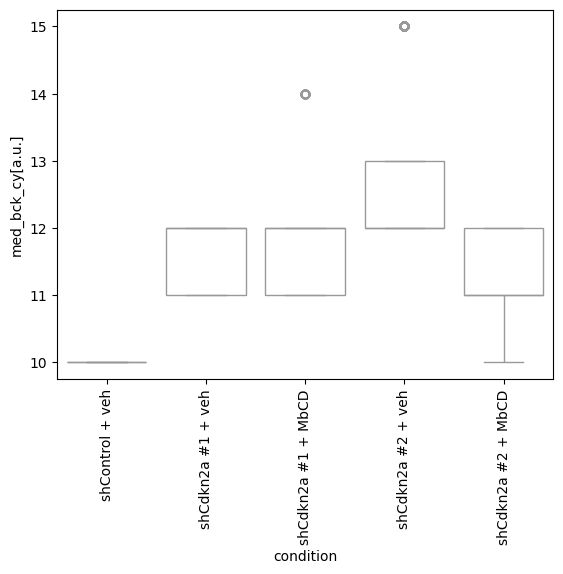

In [50]:
# compare backgroud values - test for the outliers
sns.boxplot(data = df, x = 'condition', y = 'med_bck_cy',color='white', order=order, showfliers=True)
plt.xticks(rotation=90)
plt.ylabel('med_bck_cy[a.u.]')

Text(0, 0.5, 'med_bck_cy[a.u.]')

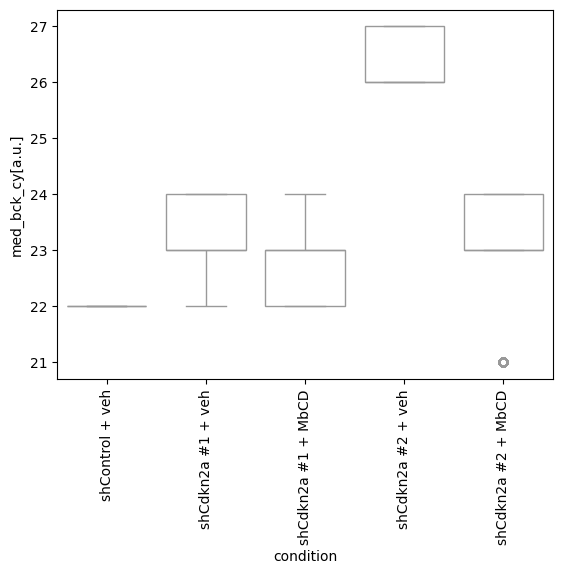

In [51]:
# compare backgroud values - test for the outliers
sns.boxplot(data = df, x = 'condition', y = 'med_bck_fitc',color='white', order=order, showfliers=True)
plt.xticks(rotation=90)
plt.ylabel('med_bck_cy[a.u.]')

In [20]:
# no outliers in the background calculation, 
# all values can be used for the correction

df['dapi_corr'] = df['intensity_mean-0'] - df['med_bck_dapi']
df['fitc_corr'] = df['intensity_mean-1'] - df['med_bck_fitc']
df['cy_corr'] = df['intensity_mean-2'] - df['med_bck_cy']

Text(38.347222222222214, 0.5, 'Mean fluorescence intensity Slc39a9 (cell area) [a.u.]')

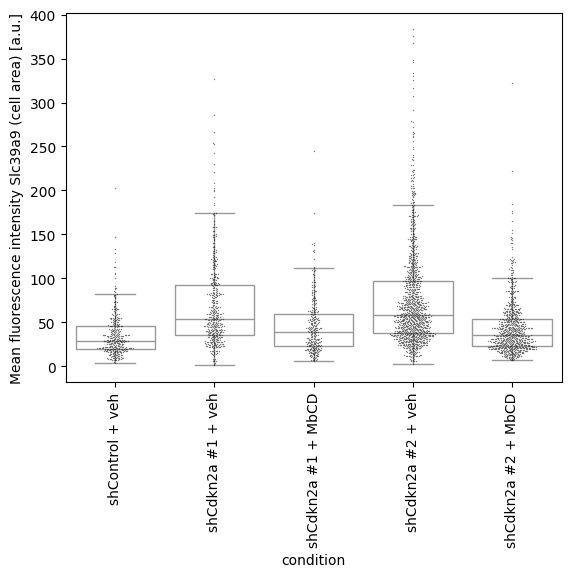

In [ ]:
# Slc39a9 signal between the conditions
sns.boxplot(data = df, x = 'condition', y = 'cy_corr',color='white',order=order,showfliers=False)
sns.swarmplot(data = df, x = 'condition', y = 'cy_corr',color='black',order=order,size = 1,alpha =0.5)
plt.xticks(rotation=90)
plt.ylabel('Mean fluorescence intensity Slc39a9 (cell area) [a.u.]')

d:\Kasia\projects\2026_Raquel_coloc\.venv\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 6.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
d:\Kasia\projects\2026_Raquel_coloc\.venv\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 7.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
d:\Kasia\projects\2026_Raquel_coloc\.venv\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 5.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


Text(29.597222222222214, 0.5, 'Mean fluorescence lipid rafts (cell area) [a.u.]')

d:\Kasia\projects\2026_Raquel_coloc\.venv\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 5.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
d:\Kasia\projects\2026_Raquel_coloc\.venv\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 5.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


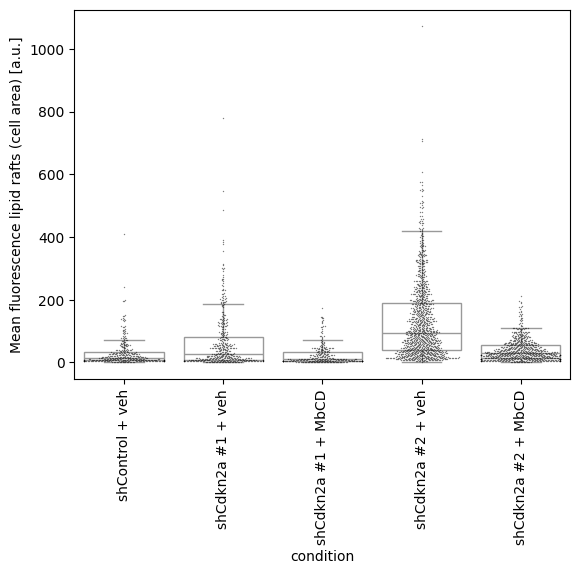

In [ ]:
# distribution of the lipid rafts signal between the conditions
sns.boxplot(data = df, x = 'condition', y = 'fitc_corr',color='white',order=order,showfliers=False)
sns.swarmplot(data = df, x = 'condition', y = 'fitc_corr',color='black',order=order,size = 1,alpha =0.5)
plt.xticks(rotation=90)
plt.ylabel('Mean fluorescence lipid rafts (cell area) [a.u.]')

## Cy and FITC signals correlations on the cell level

<Axes: xlabel='fitc_corr', ylabel='cy_corr'>

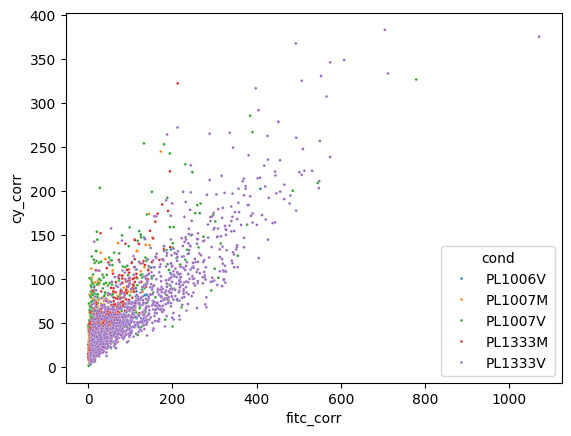

In [24]:
sns.scatterplot(data=df,x='fitc_corr',y='cy_corr',s=4, hue='cond')

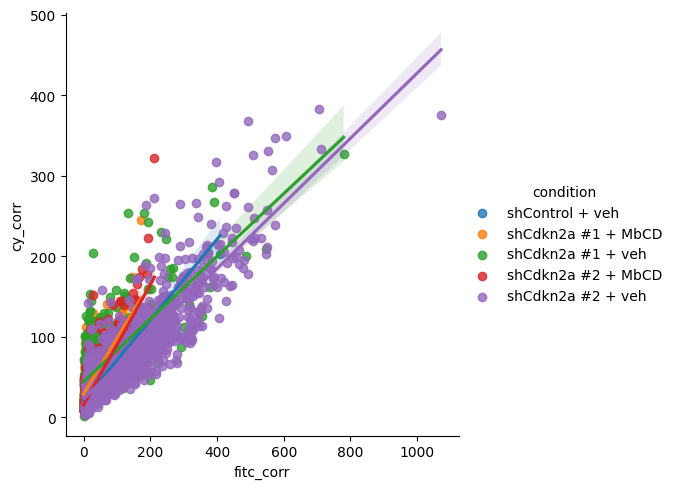

In [25]:
sns.lmplot(data=df,x='fitc_corr',y='cy_corr',hue='condition')

In [26]:
import pandas as pd
import scipy.stats as stats

# Create an empty list to store the results
stats_list = []

# Loop through each unique condition
for condition, group in df.groupby('condition'):
    # Run the linear regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(group['fitc_corr'], group['cy_corr'])
    
    # Append results to the list
    stats_list.append({
        'Condition': condition,
        'Slope': slope,
        'Intercept': intercept,
        'R-squared': r_value**2,
        'P-value': p_value,
        'Std Error': std_err
    })

# Convert to a DataFrame for easy viewing
stats_df = pd.DataFrame(stats_list)
print(stats_df)

            Condition     Slope  Intercept  R-squared        P-value  \
0  shCdkn2a #1 + MbCD  0.689412  28.882139   0.482595   5.899278e-42   
1   shCdkn2a #1 + veh  0.389290  43.965013   0.512824   2.315806e-68   
2  shCdkn2a #2 + MbCD  0.746685  15.250526   0.698361  2.236664e-197   
3   shCdkn2a #2 + veh  0.404680  22.483888   0.770835   0.000000e+00   
4     shControl + veh  0.500609  20.679473   0.730680   9.798469e-98   

   Std Error  
0   0.042660  
1   0.018405  
2   0.017919  
3   0.006579  
4   0.016581  


On average, Cdkn2a knockdown (KD) cells have significantly higher Slc39a9 intensity and total lipid raft pools than control cells. 

However, the KD vehicle groups show a flatter regression slope, indicating that the tight coupling between raft abundance and Slc39a9 expression is partially decoupled at the whole-cell level.

MbCD treatment causes a severe drop in total cellular lipid raft content, whereas whole-cell Slc39a9 levels decrease less. Despite this overall raft depletion, the correlation between lipid rafts and Slc39a9 becomes significantly stronger. This indicates that MbCD acts as a stringent filter: cells that manage to retain higher residual lipid raft levels after treatment are exclusively those possessing the highest pools of Slc39a9.

## Cy3 and FITC colocalization on pixel level

Text(31.222222222222214, 0.5, 'Spearman')

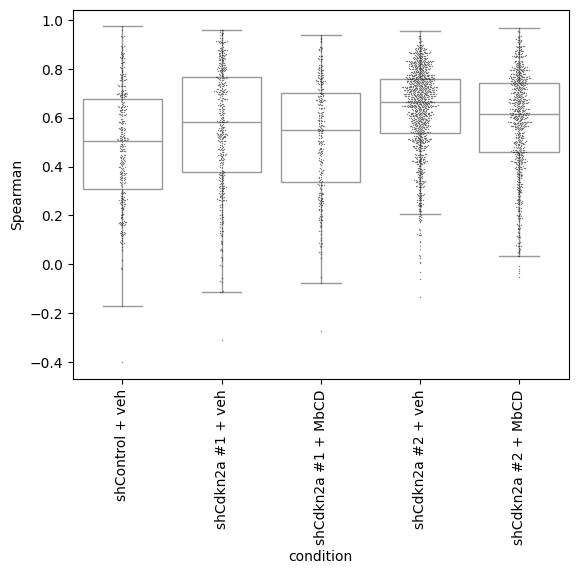

In [37]:
sns.boxplot(data = df, x = 'condition', y = 'spearman_cy_fitc',color='white',order=order,showfliers=False)
sns.swarmplot(data = df, x = 'condition', y = 'spearman_cy_fitc',color='black',order=order,size = 1,alpha =0.5)
plt.xticks(rotation=90)
plt.ylabel('Spearman')

<Axes: xlabel='fitc_corr', ylabel='spearman_cy_fitc'>

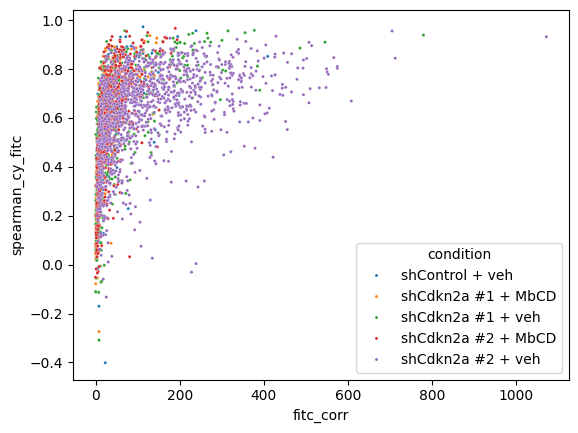

In [33]:
sns.scatterplot(data=df,x='fitc_corr',y='spearman_cy_fitc',hue='condition', s = 5)

Text(42.722222222222214, 0.5, 'Spearman, cells with rafts > 50 [a.u.]')

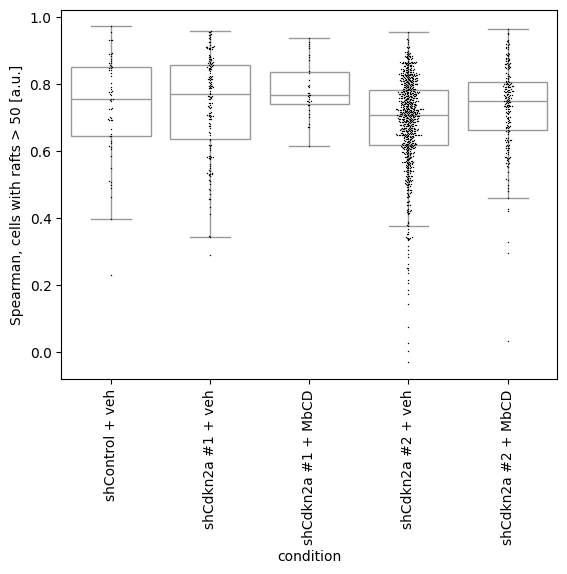

In [48]:
sns.boxplot(data=df.loc[df.fitc_corr>50,:],x='condition',y='spearman_cy_fitc',color = 'white', showfliers=False, order = order)
sns.swarmplot(data=df.loc[df.fitc_corr>50,:],x='condition',y='spearman_cy_fitc',color = 'black', s=1, order = order)
plt.xticks(rotation=90)
plt.ylabel('Spearman, cells with rafts > 50 [a.u.]')